In [1]:
# !pip uninstall -y pytabkit torch torchvision torchaudio -q
# !pip install torch torchvision torchaudio \
#     --index-url https://download.pytorch.org/whl/cu121 -q
# !pip install pytabkit -q
# !pip install optbinning

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import os

from optbinning import OptimalBinning
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
import matplotlib.pyplot as plt
import shap
import joblib
import sklearn
from datetime import datetime

## Config

In [ ]:
MAX_BIN = 5
MIN_BIN_SIZE = 0.05
AUC_BENCHMARK = 0.8

ROOT_PATH = "input_data/row_fs_data"

TARGET = 'TARGET'
ID = 'SK_ID_CURR'

MODEL_DUMP_PATH = "model_artifacts"
TEST_BEFORE_SUBMISSION = False
WOE_TRANSFORMATION = False
SUBMISSION = False

## Reading Train | Test

In [3]:
app_train = pd.read_csv(os.path.join(ROOT_PATH, "app_train_fs.csv"))
app_test = pd.read_csv(os.path.join(ROOT_PATH, "app_test_fs.csv"))

print(f"Shape of app_train : {app_train.shape} | Shape of app_test  :  {app_test.shape}")
print(f"Bad rate           : {app_train[TARGET].value_counts(normalize=True)[1].round(2) * 100} %")

Shape of app_train : (307511, 309) | Shape of app_test  :  (48744, 308)
Bad rate           : 8.0 %


## Feature Engineering

In [4]:
def engineer_credit_features(app_train, app_test):
    return app_train.copy(), app_test.copy()

app_train_fe, app_test_fe = engineer_credit_features(app_train, app_test)
print(f"Original shape (Train) : {app_train.shape} | Feature Engineered (Train) : {app_train_fe.shape}")
print(f"Original shape (Test) : {app_test.shape} | Feature Engineered (Train) : {app_test_fe.shape}")

Original shape (Train) : (307511, 309) | Feature Engineered (Train) : (307511, 309)
Original shape (Test) : (48744, 308) | Feature Engineered (Train) : (48744, 308)


## Imputation | Encoding

In [6]:
c_cols = app_test_fe.select_dtypes(include = 'object').columns.to_list()
n_cols = app_test_fe.select_dtypes(exclude = 'object').columns.to_list()

print(f"num cols : {len(n_cols)} | cat cols : {len(c_cols)} | num + cat cols : {len(n_cols + c_cols)} | total app_test cols :  {len(app_test_fe.columns)}")


# Imputation
print(f"Null values in (Train) : {app_train_fe.isnull().sum().sum()} | Null values in (Test) : {app_test_fe.isnull().sum().sum()}")
print("-" * 20, "Imputation Started", "-" * 20)
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Numerical columns
app_train_fe[n_cols] = num_imputer.fit_transform(app_train_fe[n_cols])
app_test_fe[n_cols] = num_imputer.transform(app_test_fe[n_cols])

# Categorical columns
app_train_fe[c_cols] = cat_imputer.fit_transform(app_train_fe[c_cols])
app_test_fe[c_cols] = cat_imputer.transform(app_test_fe[c_cols])

print("-" * 20, "Imputation End", "-" * 20)
print(f"Null values in (Train) : {app_train_fe.isnull().sum().sum()} | Null values in (Test) : {app_test_fe.isnull().sum().sum()}")


# Categorical Encoding
print("-" * 20, "Categorical Encoding Started", "-" * 20)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

app_train_fe[c_cols] = encoder.fit_transform(app_train_fe[c_cols])
app_test_fe[c_cols] = encoder.transform(app_test_fe[c_cols])
print("-" * 20, "Categorical Encoding End", "-" * 20)


# Feature Scaling
print("-" * 20, "Scaling Started", "-" * 20)
scale_cols = [col for col in app_train_fe.columns if col not in [ID, TARGET]]
scaler = MinMaxScaler()

app_train_fe[scale_cols] = scaler.fit_transform(app_train_fe[scale_cols])
app_test_fe[scale_cols] = scaler.transform(app_test_fe[scale_cols])
print("-" * 20, "Scaling End", "-" * 20)

print(f"Train Shape: {app_train_fe.shape} | Test Shape: {app_test_fe.shape}")
print(f"Remaining Nulls (Train): {app_train_fe.isnull().sum().sum()} | Remaining Nulls (Test): {app_test_fe.isnull().sum().sum()}")

num cols : 282 | cat cols : 26 | num + cat cols : 308 | total app_test cols :  308
Null values in (Train) : 28514976 | Null values in (Test) : 4002461
-------------------- Imputation Started --------------------
-------------------- Imputation End --------------------
Null values in (Train) : 0 | Null values in (Test) : 0
-------------------- Categorical Encoding Started --------------------
-------------------- Categorical Encoding End --------------------
-------------------- Scaling Started --------------------
-------------------- Scaling End --------------------
Train Shape: (307511, 309) | Test Shape: (48744, 308)
Remaining Nulls (Train): 0 | Remaining Nulls (Test): 0


## WoE / IV (Optbinning)

In [7]:
if WOE_TRANSFORMATION:
    feat_cols = [col for col in app_train_fe.columns if col not in [TARGET, ID]]
    iv_report = []

    train_woe_report = {
        ID: app_train_fe[ID],
        TARGET: app_train_fe[TARGET]
    }

    test_woe_report = {
        ID: app_test_fe[ID]
    }

    for col in feat_cols:

        feat = app_train_fe[col]
        target = app_train_fe[TARGET]

        opt = OptimalBinning(
            name=col,
            dtype="numerical" if pd.api.types.is_numeric_dtype(feat) else "categorical",
            max_n_bins=MAX_BIN,
            min_bin_size=MIN_BIN_SIZE
        )

        opt.fit(feat, target)

        # IV Report
        bin_info = opt.binning_table.build()
        iv = bin_info["IV"].sum()

        iv_report.append({
            "feature": col,
            "iv": iv
        })

        # WoE transformed features
        train_woe_report[col] = opt.transform(feat, metric="woe")
        test_woe_report[col] = opt.transform(app_test_fe[col], metric="woe")

    app_train_woe = pd.DataFrame(train_woe_report)
    app_test_woe = pd.DataFrame(test_woe_report)

    iv_report = (
        pd.DataFrame(iv_report)
        .sort_values("iv", ascending=False)
    )

    print(f"Shape of train (ORG) : {app_train_fe.shape}  | Shape of test (ORG) : {app_test_fe.shape}")
    print(f"Shape of train (WoE) : {app_train_woe.shape} | Shape of test (WoE) : {app_test_woe.shape}")

## WoE + LightGBM Training

In [8]:
if WOE_TRANSFORMATION and TEST_BEFORE_SUBMISSION:
    X, y = app_train_woe.drop([ID, TARGET], axis=1), app_train_woe[TARGET]
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
    print(f"Scale Pos Weight : {scale_pos_weight}")


    LIGHTGBM_PARAMS = {
        'objective':"binary",
        'metric':"auc",
        'boosting_type':"gbdt",
        'n_estimators':10000,
        'learning_rate':0.05,
        'num_leaves':31,
        'max_depth':-1,
        'min_child_samples':20,
        'subsample':0.8,
        'colsample_bytree':0.8,
        'scale_pos_weight':scale_pos_weight,
        'random_state':42,
        'n_jobs':-1,
        'verbosity':-1
    }


    base_model = lgb.LGBMClassifier(
        **LIGHTGBM_PARAMS
    )


    base_model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=100)
        ]
    )

    y_pred_train = base_model.predict_proba(X_train, num_iteration=base_model.best_iteration_)[:, 1]
    y_pred_valid = base_model.predict_proba(X_valid, num_iteration=base_model.best_iteration_)[:, 1]

    train_auc_score = roc_auc_score(y_train, y_pred_train)
    train_gini_score = 2 * train_auc_score - 1

    valid_auc_score = roc_auc_score(y_valid, y_pred_valid)
    valid_gini_score = 2 * valid_auc_score - 1

    print("\n" + "=" * 60)
    print(f"Best Iteration : {base_model.best_iteration_}")
    print("-" * 60)
    print(f"Train AUC      : {train_auc_score:.6f}")
    print(f"Train Gini     : {train_gini_score:.6f}")
    print("-" * 60)
    print(f"Valid AUC      : {valid_auc_score:.6f} | Benchmark: {AUC_BENCHMARK}")
    print(f"Valid Status   : {'Passed' if valid_auc_score >= AUC_BENCHMARK else 'Below Benchmark'}")
    print(f"Valid Gini     : {valid_gini_score:.6f}")
    print("-" * 60)
    print(f"AUC Gap        : {train_auc_score - valid_auc_score:.6f}")
    print("=" * 60)

## ORG + LightGBM Training

In [9]:
X, y = app_train_fe.drop([ID, TARGET], axis=1), app_train_fe[TARGET]
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Scale Pos Weight : {scale_pos_weight}")


LIGHTGBM_PARAMS = {
    'objective':"binary",
    'metric':"auc",
    'boosting_type':"gbdt",
    'n_estimators':10000,
    'learning_rate':0.05,
    'num_leaves':31,
    'max_depth':-1,
    'min_child_samples':20,
    'subsample':0.8,
    'colsample_bytree':0.8,
    'scale_pos_weight':scale_pos_weight,
    'random_state':42,
    'n_jobs':-1,
    'verbosity':-1
}


base_model = lgb.LGBMClassifier(
    **LIGHTGBM_PARAMS
)


base_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

y_pred_train = base_model.predict_proba(X_train, num_iteration=base_model.best_iteration_)[:, 1]
y_pred_valid = base_model.predict_proba(X_valid, num_iteration=base_model.best_iteration_)[:, 1]

train_auc_score = roc_auc_score(y_train, y_pred_train)
train_gini_score = 2 * train_auc_score - 1

valid_auc_score = roc_auc_score(y_valid, y_pred_valid)
valid_gini_score = 2 * valid_auc_score - 1

print("\n" + "=" * 60)
print(f"Best Iteration : {base_model.best_iteration_}")
print("-" * 60)
print(f"Train AUC      : {train_auc_score:.6f}")
print(f"Train Gini     : {train_gini_score:.6f}")
print("-" * 60)
print(f"Valid AUC      : {valid_auc_score:.6f} | Benchmark: {AUC_BENCHMARK}")
print(f"Valid Status   : {'Passed' if valid_auc_score >= AUC_BENCHMARK else 'Below Benchmark'}")
print(f"Valid Gini     : {valid_gini_score:.6f}")
print("-" * 60)
print(f"AUC Gap        : {train_auc_score - valid_auc_score:.6f}")
print("=" * 60)

Scale Pos Weight : 11.38710976837865
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.775122
[200]	valid_0's auc: 0.781079
[300]	valid_0's auc: 0.78219
[400]	valid_0's auc: 0.782471
Early stopping, best iteration is:
[370]	valid_0's auc: 0.782624

Best Iteration : 370
------------------------------------------------------------
Train AUC      : 0.857571
Train Gini     : 0.715142
------------------------------------------------------------
Valid AUC      : 0.782624 | Benchmark: 0.8
Valid Status   : Below Benchmark
Valid Gini     : 0.565248
------------------------------------------------------------
AUC Gap        : 0.074947


## Final Model Training

In [ ]:
final_model = lgb.LGBMClassifier(
    **{**LIGHTGBM_PARAMS, "n_estimators": base_model.best_iteration_}
)

final_model.fit(X, y)

print(f"Dumping Trained LightGBM with artifacts ...")
model_artifact = {
    "model": final_model,
    "metadata": {
        "model_name": "home_credit_lgbm",
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "target_column": TARGET,
        "input_features": list(X.columns),
        "feature_dtypes": {
            col: str(dtype)
            for col, dtype in X.dtypes.items()
        },
        "output_schema": {
            "prediction_probability": "float",
            "prediction_class": "int"
        },
        "model_metrics": {
            "train_auc": train_auc_score,
            "train_gini": train_gini_score,
            "valid_auc": valid_auc_score,
            "valid_gini": valid_gini_score
        },
        "library_versions": {
            "lightgbm": lgb.__version__,
            "sklearn": sklearn.__version__
        }
    },
    
    "preprocessing": {
        "num_imputer": num_imputer,
        "cat_imputer": cat_imputer,
        "encoder": encoder,
        "scaler": scaler
    }
}

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = os.path.join(MODEL_DUMP_PATH, f"home_credit_lgbm_{timestamp}.pkl")

joblib.dump(
    model_artifact,
    model_path,
    compress=3
)

print(f"Model is dumped to : {model_path}")

Dumping Trained LightGBM with artifacts ...
Model is dumped to : trained_models\home_credit_lgbm_20260531_172756.pkl


In [ ]:
if SUBMISSION:
    test_pred = final_model.predict_proba(
        app_test_fe.drop(ID, axis=1),
        num_iteration=final_model.best_iteration_
    )[:, 1]

    submission = pd.DataFrame({
        ID: app_test_fe[ID].astype(int),
        TARGET: test_pred
    })

    submission.to_csv("submission_v2.csv", index=False)
    print(submission.head())
    print(f"\nSubmission Shape: {submission.shape}")

    print(submission[TARGET].describe())
    print("\nMissing Predictions:", submission[TARGET].isnull().sum())
    print("\nDuplicate IDs:", submission[ID].duplicated().sum())

   SK_ID_CURR    TARGET
0      100001  0.357839
1      100005  0.559640
2      100013  0.183281
3      100028  0.274961
4      100038  0.667997

Submission Shape: (48744, 2)
count    48744.000000
mean         0.363003
std          0.214527
min          0.012601
25%          0.180488
50%          0.326652
75%          0.524188
max          0.949033
Name: TARGET, dtype: float64

Missing Predictions: 0

Duplicate IDs: 0


## Top 10 important features by (Gain)

In [12]:
feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": base_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 Features")
display(feature_importance.head(10))


Top 20 Features


,feature,importance
0,EXT_SOURCE_1,299
1,EXT_SOURCE_3,278
2,EXT_SOURCE_2,261
3,AMT_ANNUITY,259
4,DAYS_BIRTH,244
5,AMT_CREDIT,233
6,DAYS_EMPLOYED,184
7,AMT_PAYMENT_MIN_inst_pmt,182
8,AMT_GOODS_PRICE,182
9,DAYS_ID_PUBLISH,161


## Top 10 important features by (shap values)

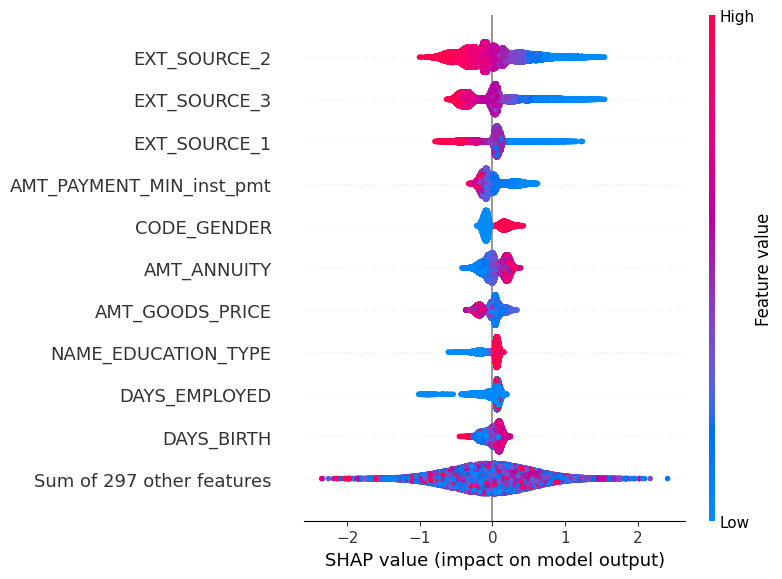

In [13]:
explainer = shap.TreeExplainer(base_model)
shap_values = explainer(X_valid)

plt.figure(figsize=(10, 6))

shap.plots.beeswarm(shap_values, max_display=11, show=False)

plt.tight_layout()
plt.show()

## ROC Curve

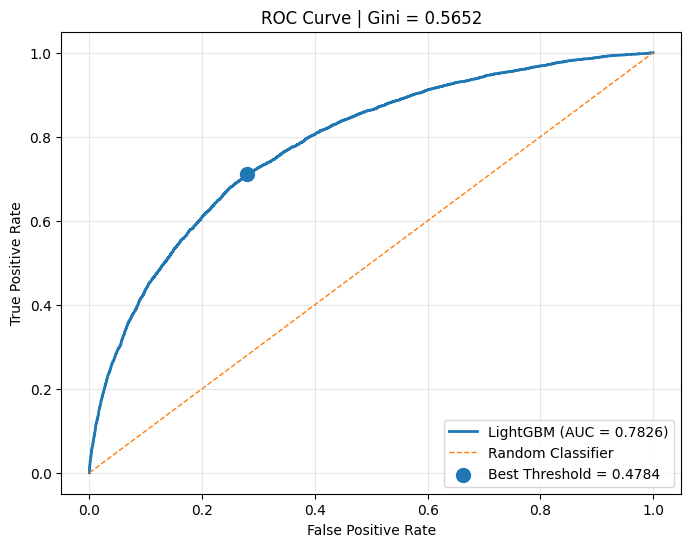

AUC Score      : 0.782624
Gini Score     : 0.565248
Best Threshold : 0.478353


In [14]:
y_pred_proba = base_model.predict_proba(X_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, y_pred_proba)
auc = roc_auc_score(y_valid, y_pred_proba)
gini = 2 * auc - 1

best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'LightGBM (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], '--', lw=1, label='Random Classifier')
plt.scatter(fpr[best_idx], tpr[best_idx], s=100,
            label=f'Best Threshold = {best_threshold:.4f}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve | Gini = {gini:.4f}')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.show()

print(f"AUC Score      : {auc:.6f}")
print(f"Gini Score     : {gini:.6f}")
print(f"Best Threshold : {best_threshold:.6f}")